# Import packages

In [2]:
options(stringsAsFactors = FALSE)
library(CellChat)
library(Seurat)
library(tidyverse)
library(viridis)
library(RColorBrewer)

# Create Cellchat object

In [22]:
seu=readRDS('/home/lixinxing/IBD/data_sc/soupX/soupX_new/adata_sc_3.rds')

counts    <- GetAssayData(seu, assay="RNA", slot="counts")
meta      <- seu@meta.data
meta$labels <- meta$subtype_anno_2
data.input <- as(log1p(t(t(counts) / Matrix::colSums(counts) * 1e4)), "dgCMatrix")

In [21]:
cellchat <- createCellChat(object = data.input, group.by = "subtype_anno_2")
cellchat <- addMeta(cellchat, meta = meta)
cellchat <- setIdent(cellchat, ident.use = "subtype_anno_2") # set "labels" as default cell identity
levels(cellchat@idents) # show factor levels of the cell labels
groupSize <- as.numeric(table(cellchat@idents)) # number of cells in each cell group

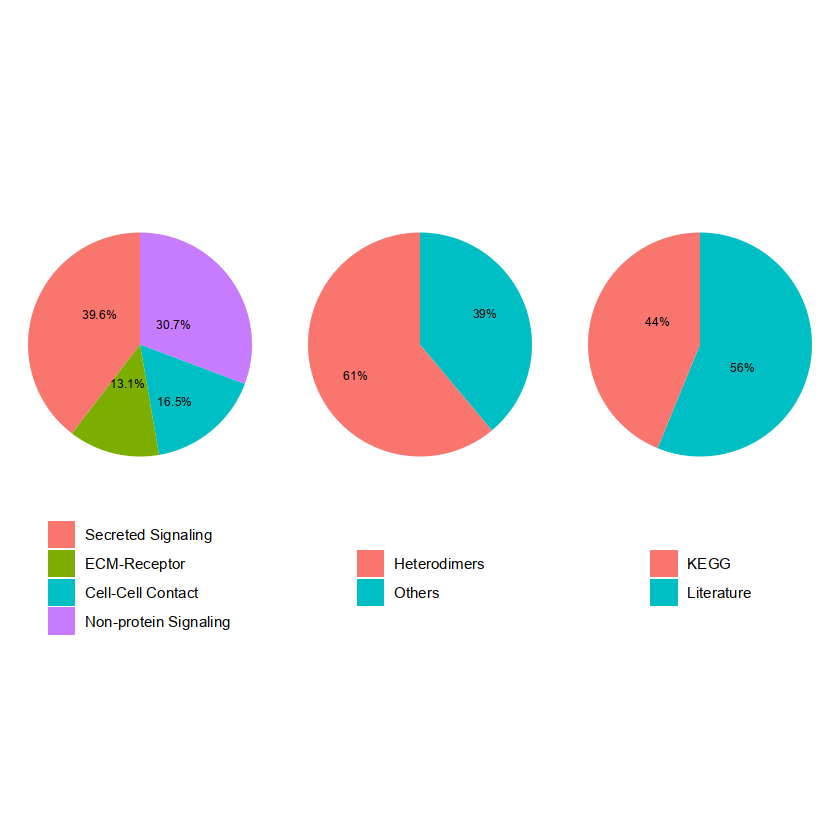

In [11]:
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

# Compute communication probabilities and infer cell-cell interaction networks

In [7]:
options(future.globals.maxSize = 3000 * 1024^2)  

In [ ]:
CellChatDB.use <- CellChatDB 
cellchat@DB <- CellChatDB.use

cellchat <- subsetData(cellchat) 
future::plan("multisession", workers = 6) 
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”


In [9]:
ptm = Sys.time()
cellchat <- computeCommunProb(cellchat, type = "triMean")

[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-02-10 19:23:21]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-02-10 21:40:17]"


In [10]:
cellchat <- filterCommunication(cellchat, min.cells = 5)
cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "igno

In [11]:
# saveRDS(cellchat,file='./sc_analysis_cellchat_subtype_60.rds')

## sfig 11c

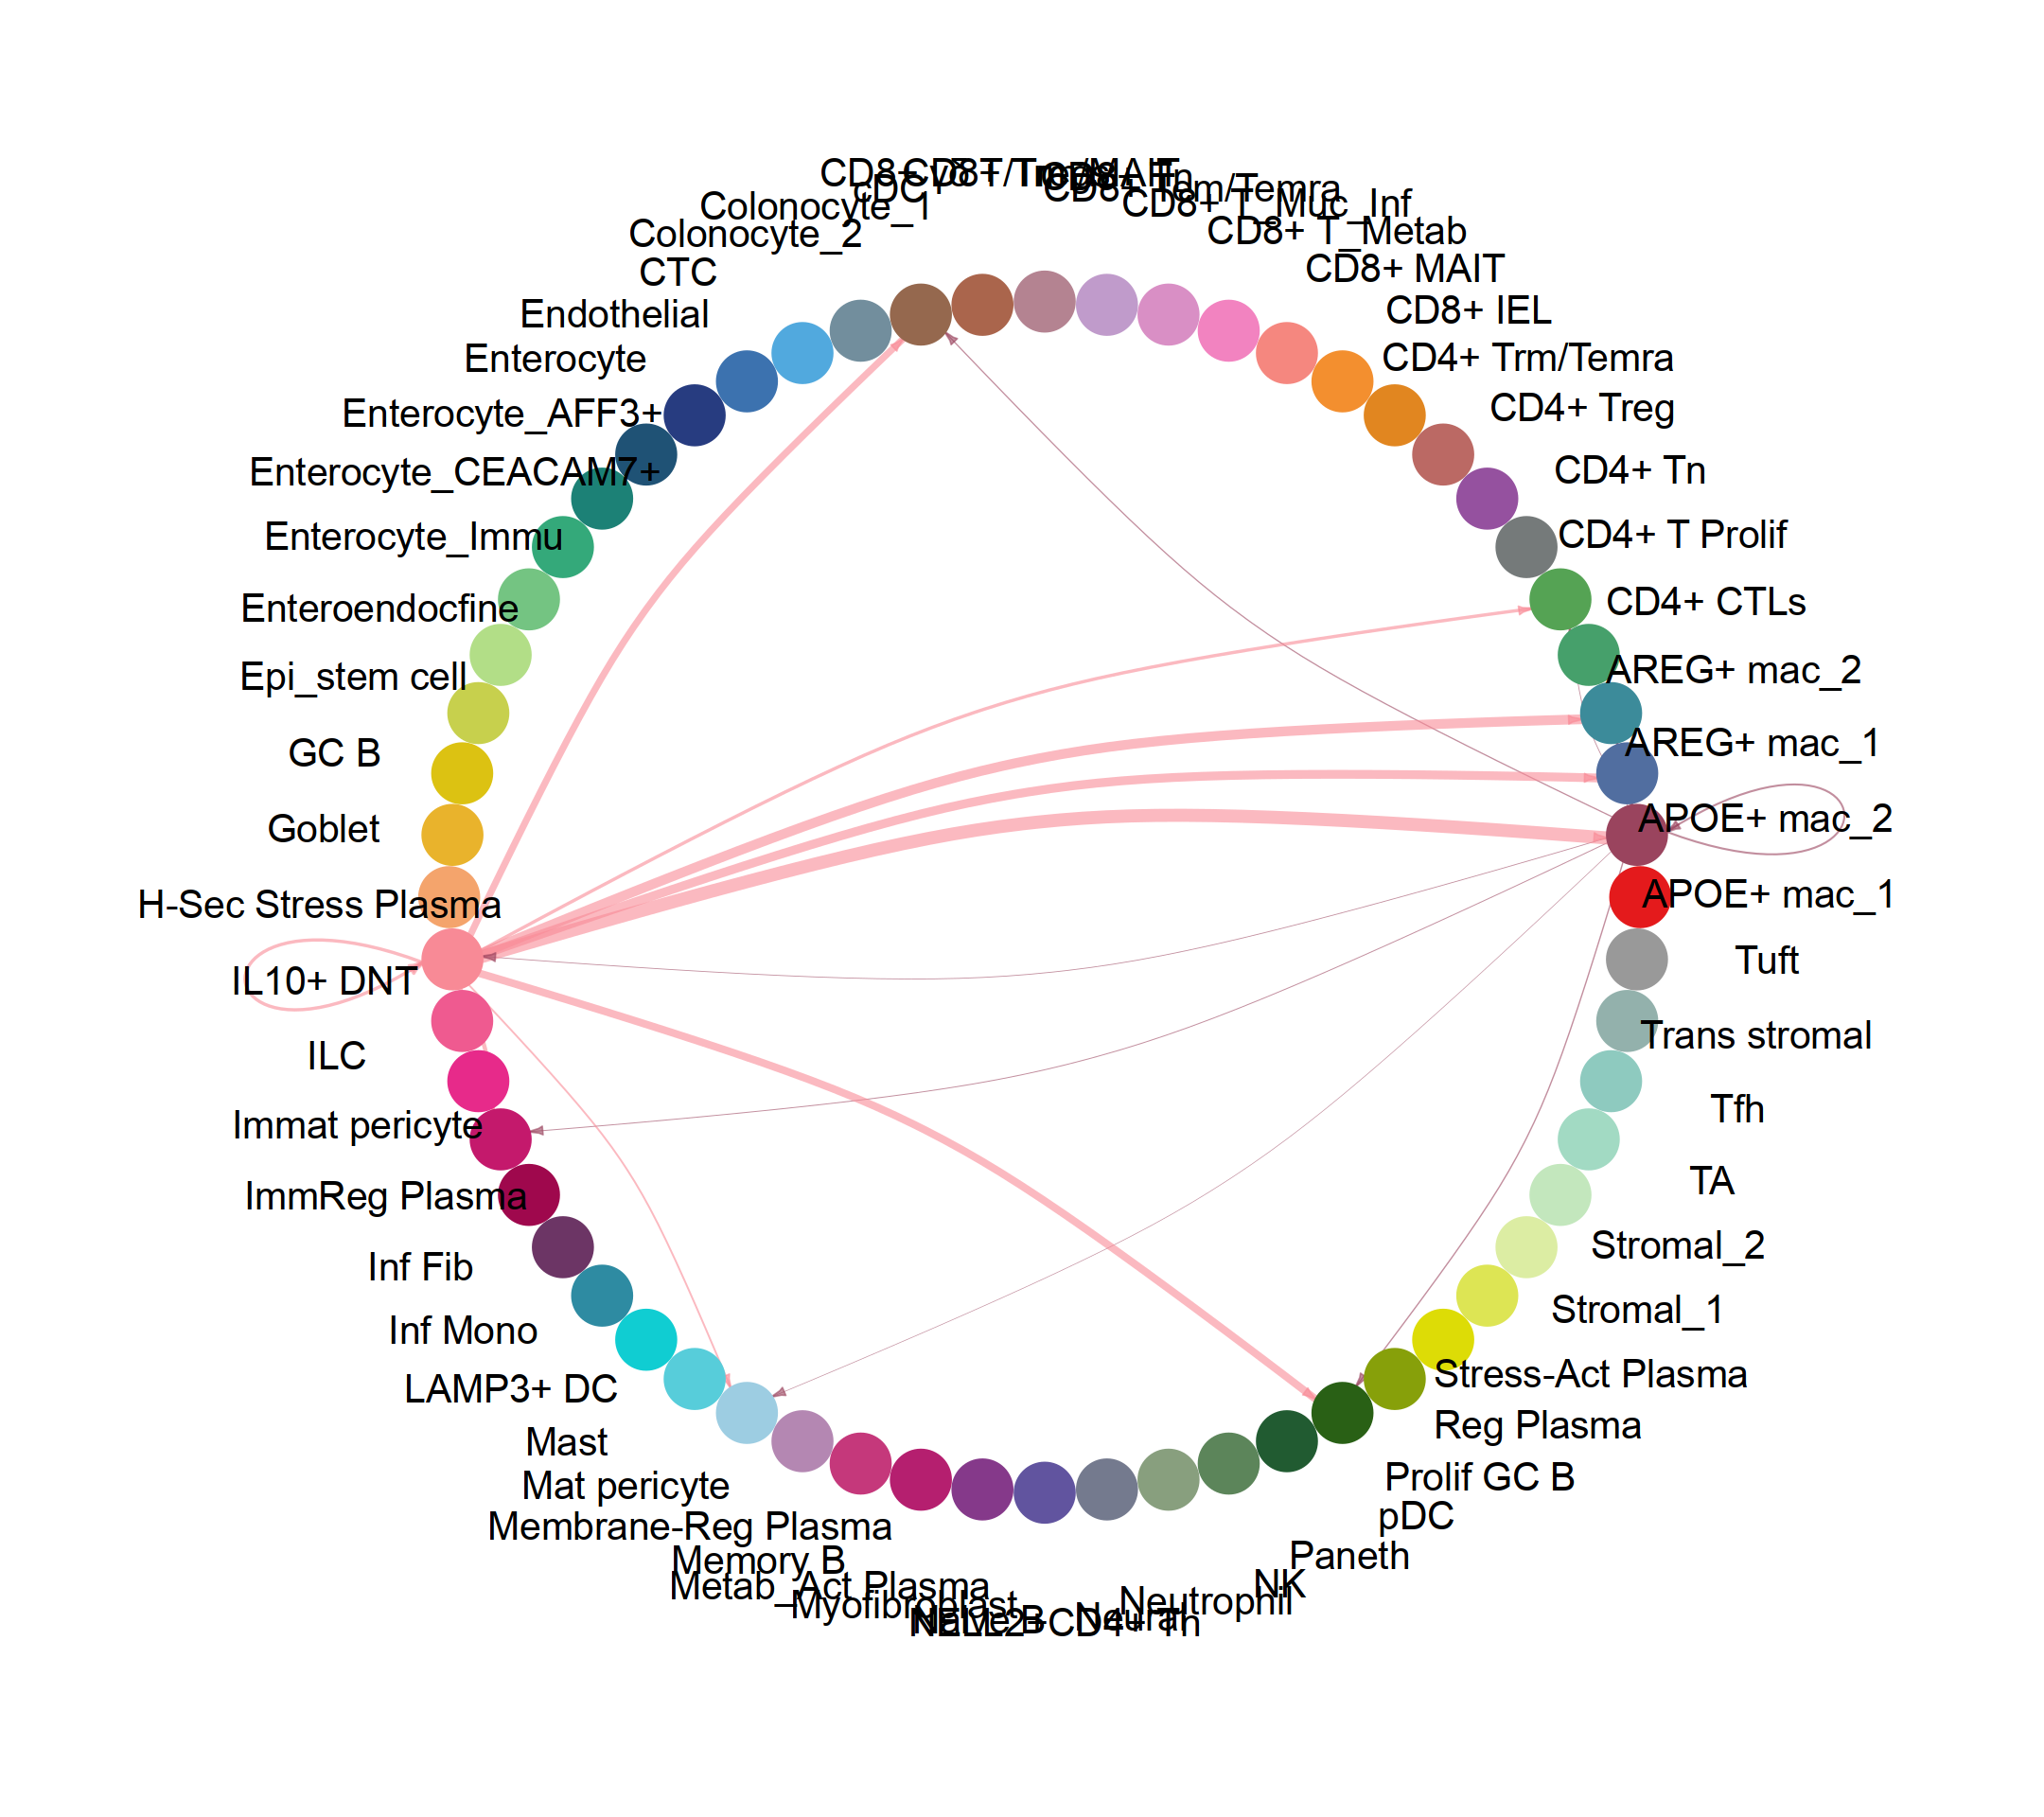

In [25]:
pathways.show <- c("IL10") 
h1<-netVisual_aggregate(cellchat, signaling = pathways.show,thresh = 0.01,vertex.label.cex = 2)

In [34]:
pdf('./IL10_path_60_2.pdf',width = 15,height = 15)
pathways.show <- c("IL10") 
h1<-netVisual_aggregate(cellchat, signaling = pathways.show,thresh = 0.01,vertex.label.cex = 2)
dev.off()

png 
  2

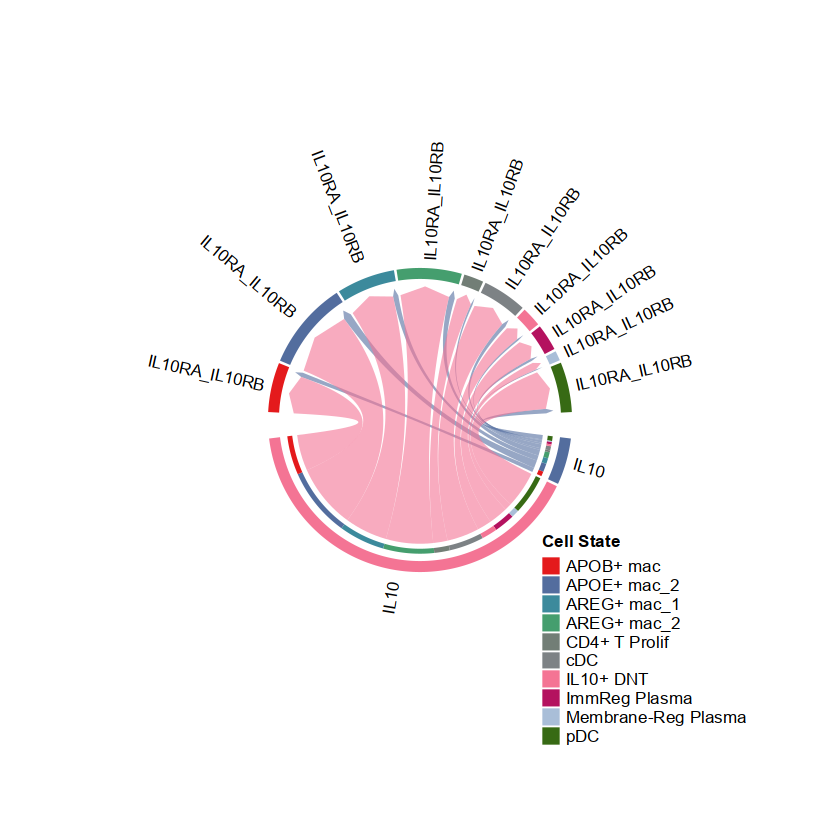

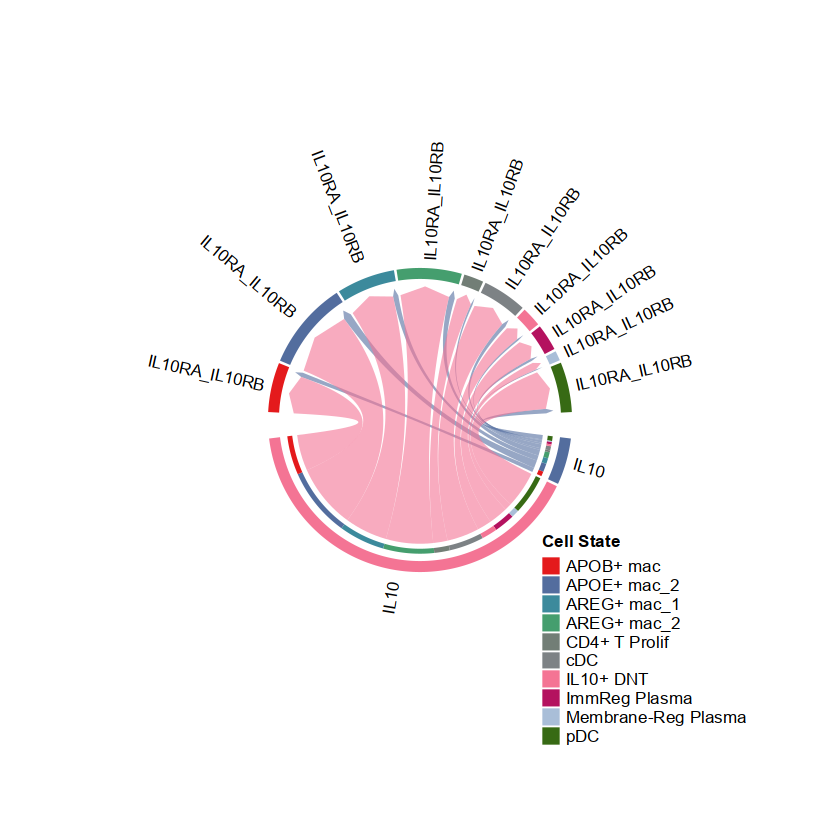

In [15]:
netVisual_chord_gene(cellchat,signaling = 'IL10')

## sfig 10b

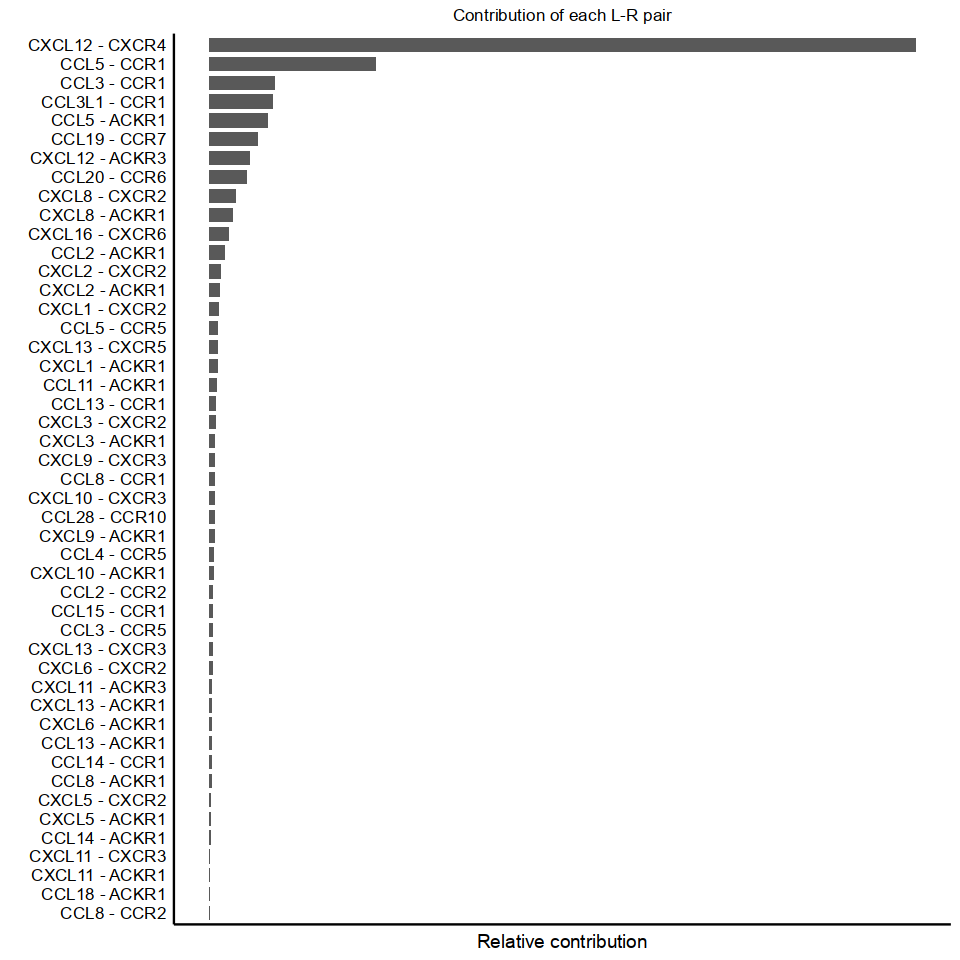

In [57]:
chemokine_pathways <- c("CCL", "CXCL", "CX3C", "XCR")
netAnalysis_contribution(cellchat, signaling = chemokine_pathways)

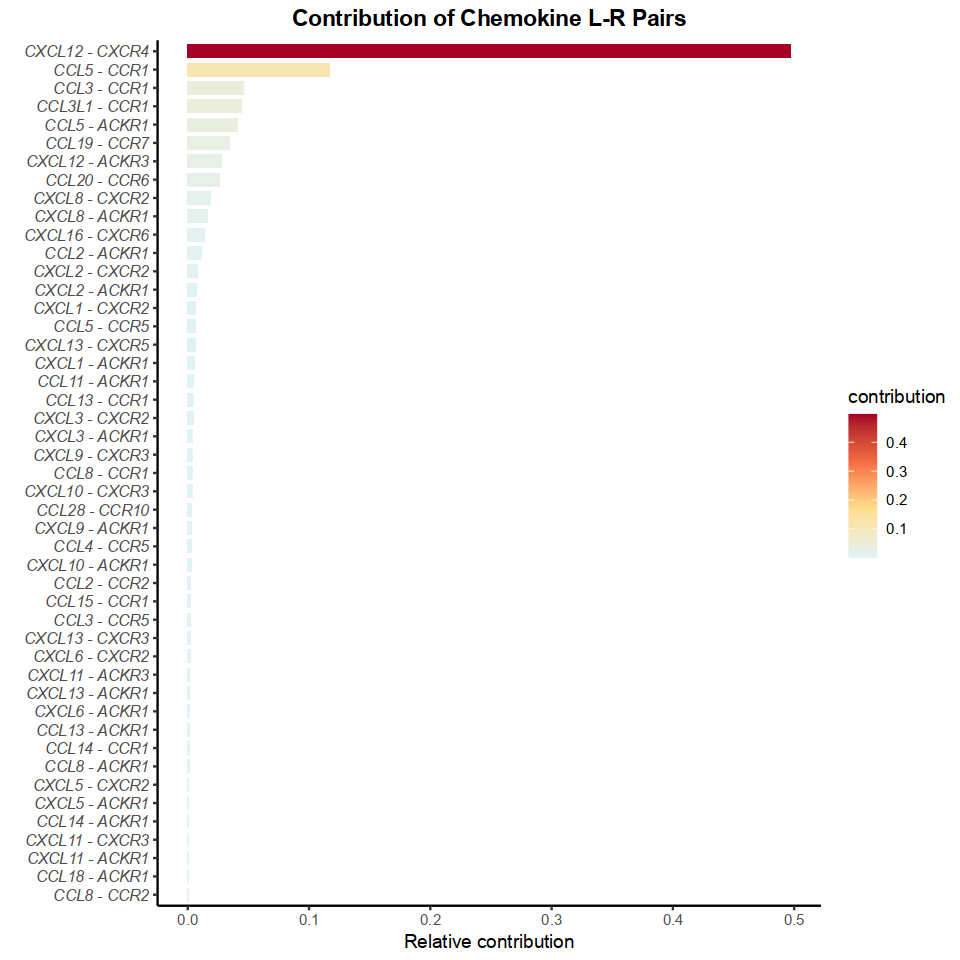

In [61]:
library(ggplot2)
library(viridis) 

chemokine_pathways <- c("CCL", "CXCL", "CX3C", "XCR")
p <- netAnalysis_contribution(cellchat, signaling = chemokine_pathways)

p_color <- p + 
  aes(fill = contribution) + 
  scale_fill_gradientn(colors = c("#e0f3f8", "#fee090", "#f46d43", "#a50026")) +
  
  theme_classic() +
  labs(title = "Contribution of Chemokine L-R Pairs") +
  theme(
    legend.position = "right",
    axis.text.y = element_text(size = 9, face = "italic"), 
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

print(p_color)

## Fig 3e

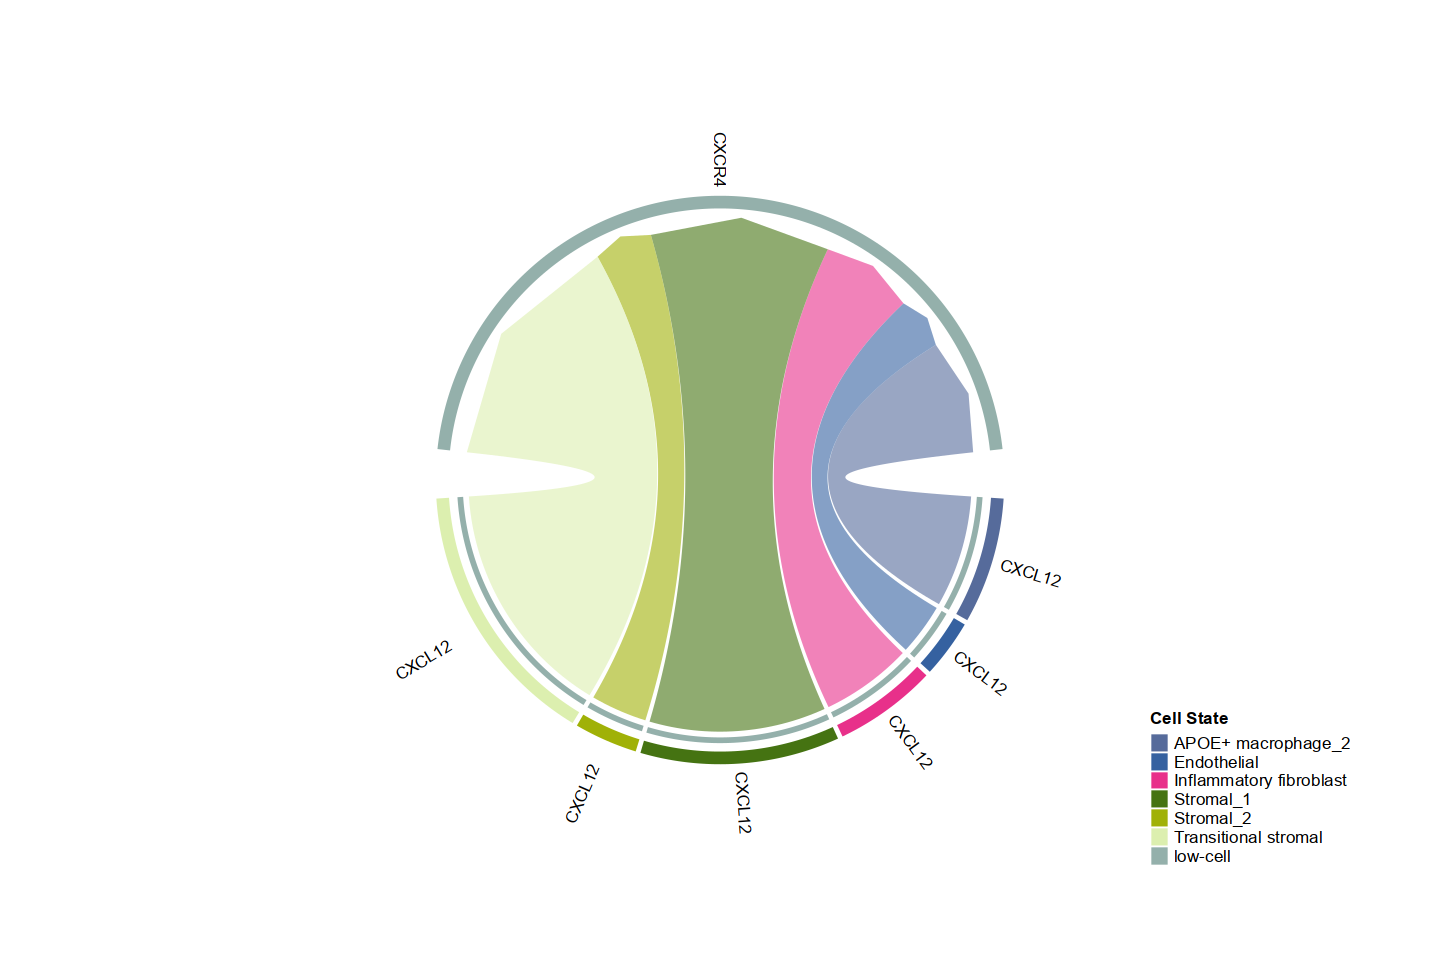

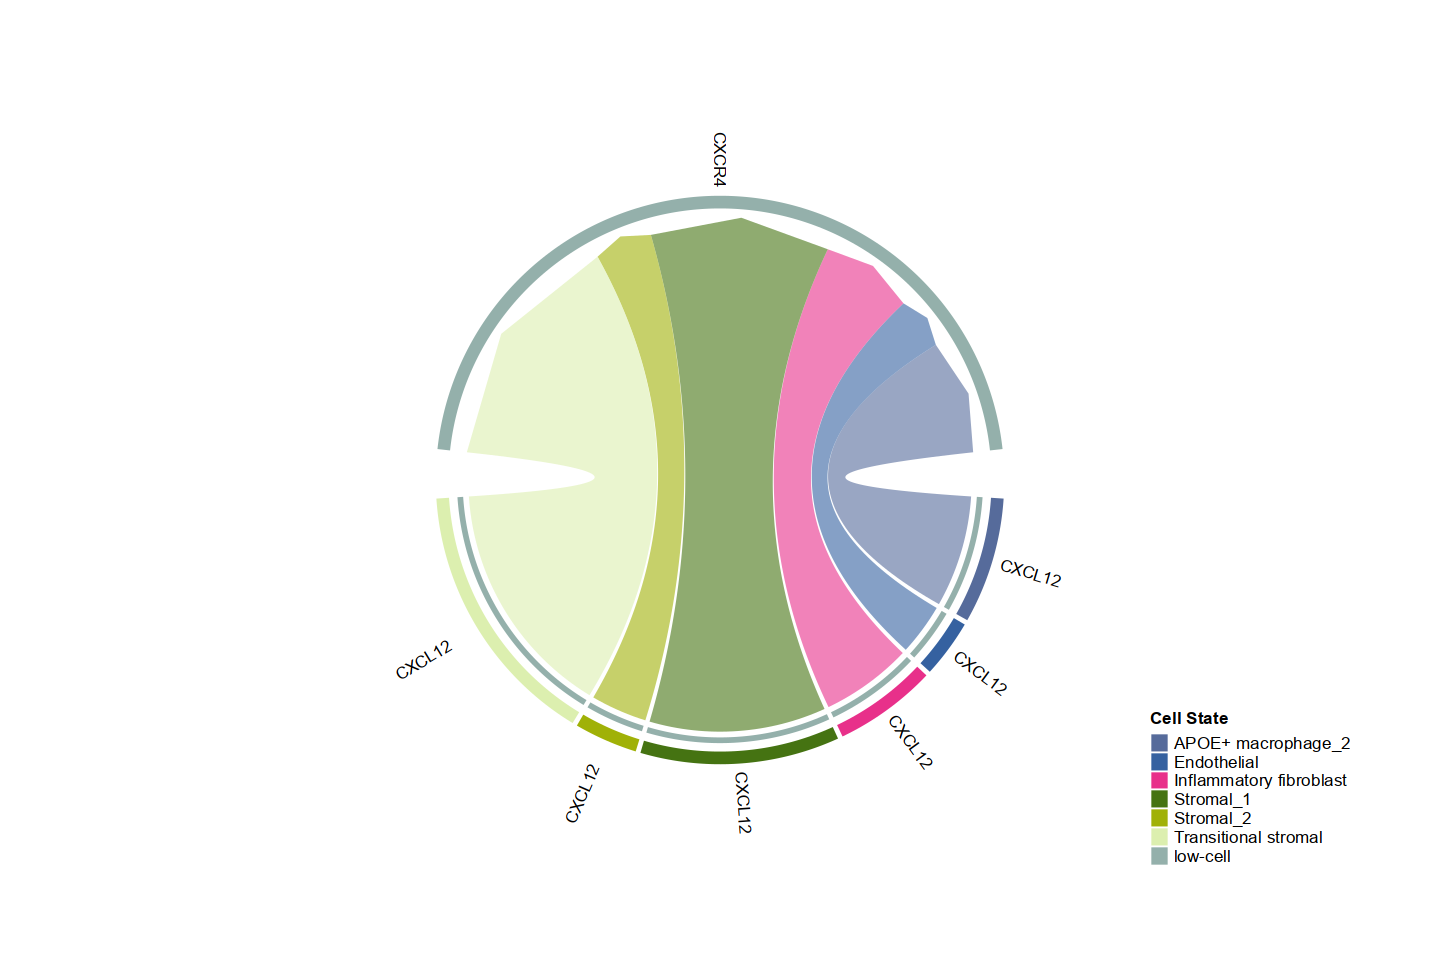

In [43]:
netVisual_chord_gene(cellchat,signaling = 'CXCL',targets.use = 'IL10+ DNT')

## Fig4F

In [7]:
cellchat<-readRDS('./sc_analysis_cellchat_dnt_mac.rds')
cellchat

An object of class CellChat created from a single dataset 
 36601 genes.
 5931 cells. 
CellChat analysis of single cell RNA-seq data! 

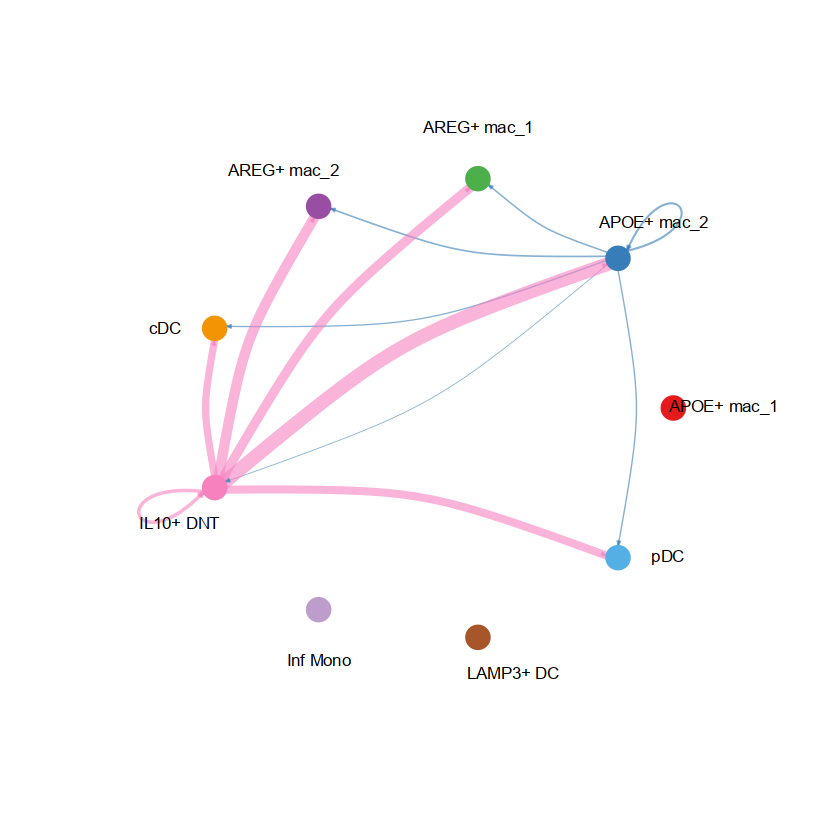

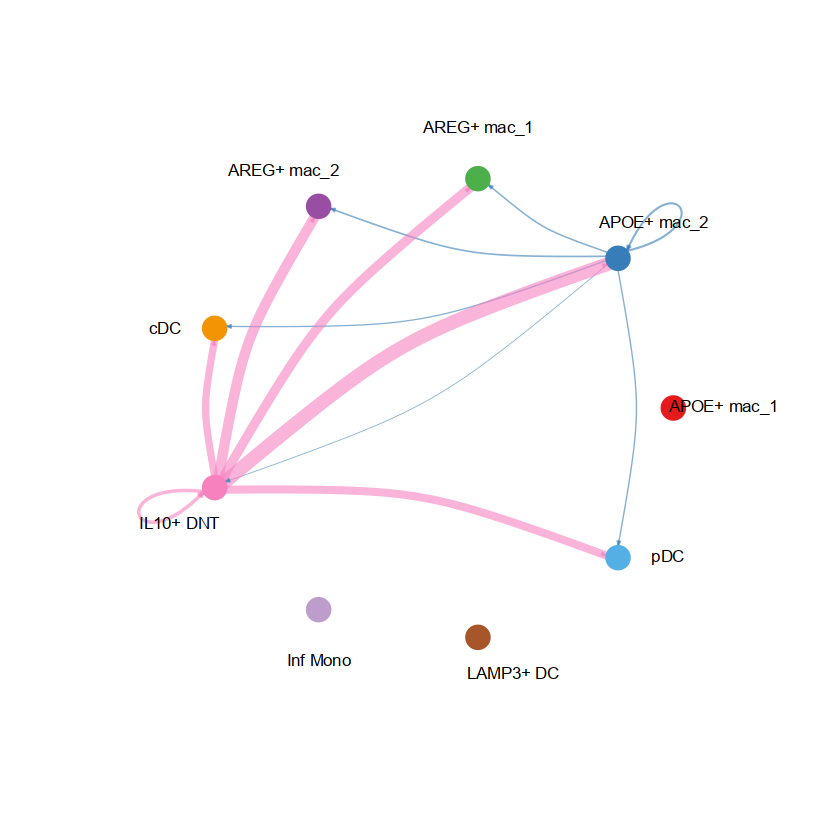

In [12]:
pathways.show <- c("IL10") 
h1<-netVisual_aggregate(cellchat, signaling = pathways.show,thresh = 0.01)
h1

In [14]:
pdf('./IL10_path_dnt_mac.pdf',width = 10,height = 10)
p<-netVisual_individual(cellchat, signaling = pathways.show)
dev.off()

png 
  2

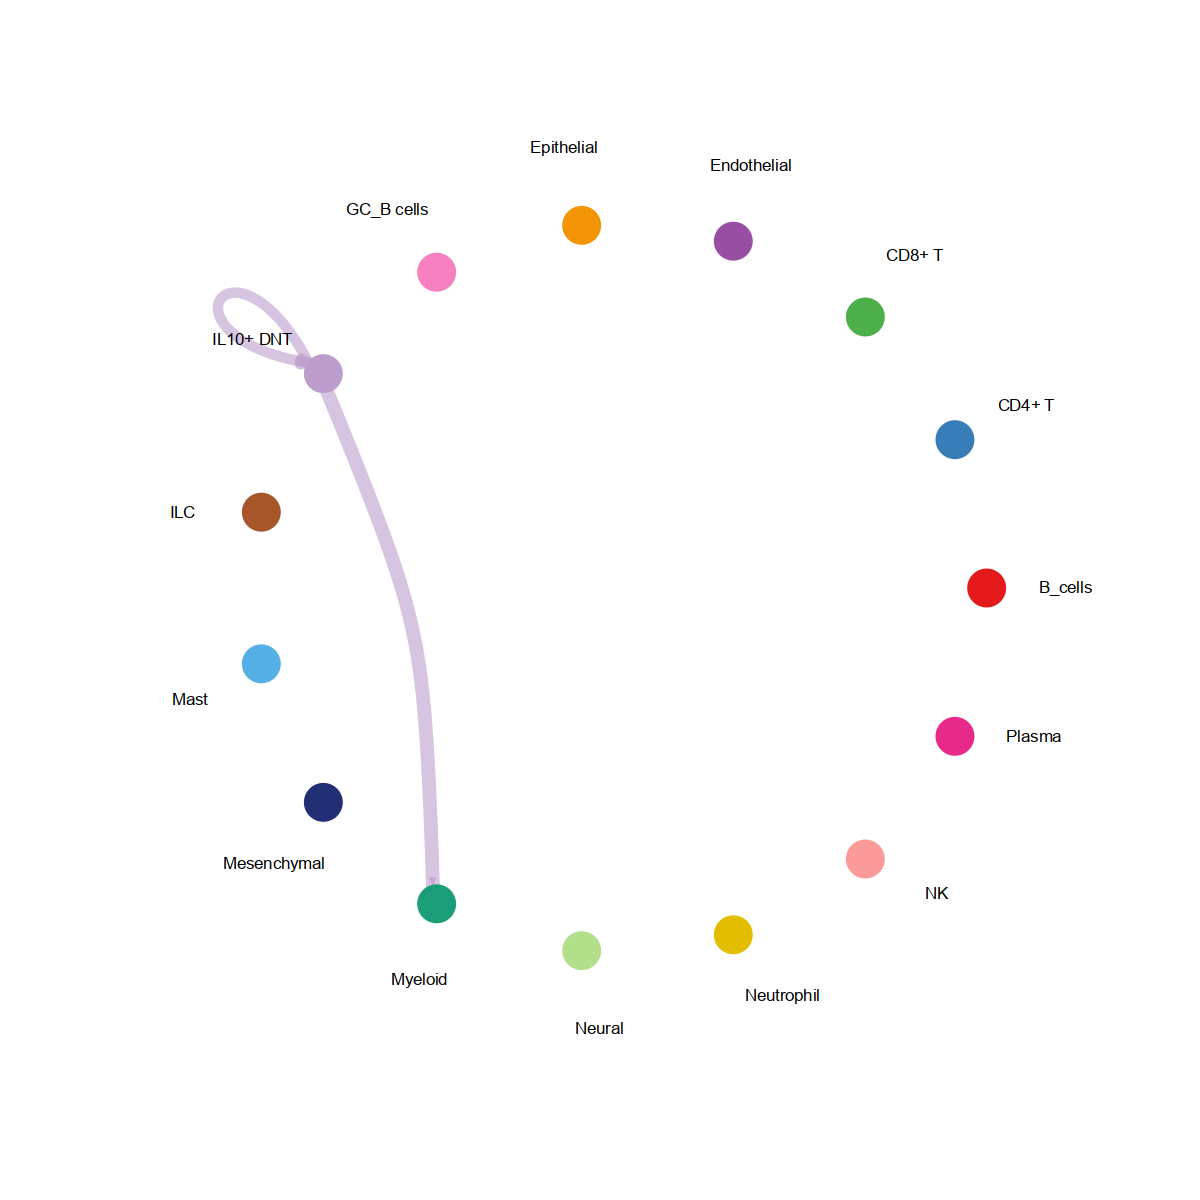

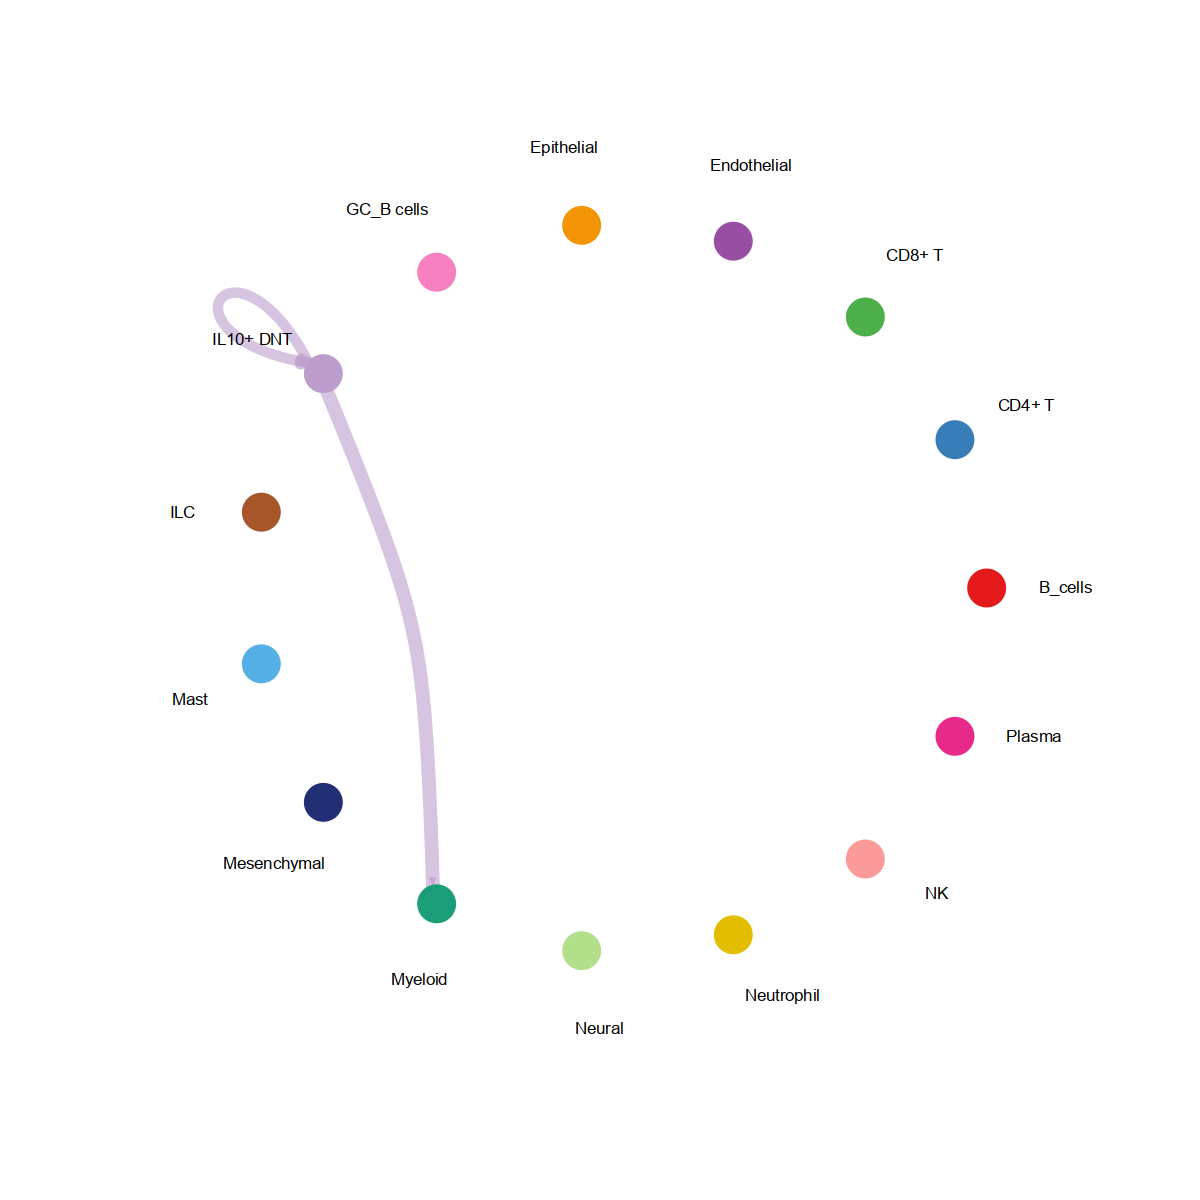

In [18]:
pathways.show <- c("IL10") 
h1<-netVisual_aggregate(cellchat, signaling = pathways.show,thresh = 0.01)
h1